# CLUTRA Plots

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def geo_mean(series, eps=1e-12):
  vals = series.to_numpy(dtype=float)
  if (vals <= 0).any():
    vals = np.maximum(vals, eps)
  return float(np.exp(np.mean(np.log(vals))))

## Measure Imbalance

### Data Parsing
Creates a CSV file containing measure imbalance data.

In [19]:
import pandas as pd
from pathlib import Path
import re
import csv

DATASETS = [
  "soc-orkut",
  "hollywood-2009",
  "indochina-2004",
]

BASE_DIR = Path("out/imbalance")
CONDITIONS = [
    ("no-stealing", BASE_DIR / "no-stealing"),
    ("stealing", BASE_DIR / "stealing"),
]

def parse_iteration_line(line: str):
    if not line.startswith("Iteration "):
        return None, None
    try:
        header, payload = line.split(":", 1)
        iter_idx = int(header.split()[1])
    except ValueError:
        return None, None

    payload = payload.strip()
    if not payload:
        return iter_idx, []

    # New layout: counts only (space-separated integers)
    if "[" not in payload:
        counts = [int(x) for x in payload.split()]
        return iter_idx, list(enumerate(counts))

    # Old layout: [block] count pairs
    pairs = []
    for block_str, edges_str in re.findall(r"\[(\d+)\]\s+(\d+)", payload):
        pairs.append((int(block_str), int(edges_str)))
    return iter_idx, pairs


def parse_file(path: Path, dataset: str, mode: str, block_writer: csv.writer, cluster_writer: csv.writer):
    run_id = -1
    for line in path.read_text().splitlines():
        if line.startswith("[*] Running"):
            run_id += 1
            continue
        iter_idx, pairs = parse_iteration_line(line)
        if iter_idx is None or pairs is None:
            continue
        total_edges = 0
        for block_id, edges in pairs:
            total_edges += edges
            block_writer.writerow([dataset, mode, run_id, iter_idx, block_id, edges])
        cluster_writer.writerow([dataset, mode, run_id, iter_idx, total_edges])

base_dir = Path("out/imbalance")
out_dir = base_dir / "parsedf"
out_dir.mkdir(parents=True, exist_ok=True)
block_csv = out_dir / "edges_per_block.csv"
cluster_csv = out_dir / "edges_per_cluster.csv"

with block_csv.open("w", newline="") as block_f, cluster_csv.open("w", newline="") as cluster_f:
    block_writer = csv.writer(block_f)
    cluster_writer = csv.writer(cluster_f)
    block_writer.writerow(["dataset", "mode", "run", "iteration", "block", "edges"])
    cluster_writer.writerow(["dataset", "mode", "run", "iteration", "edges_cluster"])

    for mode_dir in ["stealing", "no-stealing"]:
        folder = base_dir / mode_dir
        if not folder.exists():
            continue
        for path in sorted(folder.glob("*.out")):
            dataset = path.stem
            parse_file(path, dataset, mode_dir, block_writer, cluster_writer)

print(f"Wrote {block_csv}")
print(f"Wrote {cluster_csv}")


Wrote out/imbalance/parsedf/edges_per_block.csv


### Data Processing
Processes the CSV file to prepare data for plotting.

In [2]:
import numpy as np
import pandas as pd

CSV_PATH = "out/imbalance/parsedf/edges_per_block.csv"
CLUSTER_SIZE = 4


def gini(values: np.ndarray) -> float:
    if values.size == 0:
        return np.nan
    v = np.sort(values)
    n = v.size
    total = v.sum()
    if total == 0:
        return 0.0
    index = np.arange(1, n + 1)
    return (2 * (index * v).sum()) / (n * total) - (n + 1) / n


def coeff_var(values: np.ndarray) -> float:
    if values.size == 0:
        return np.nan
    mean = values.mean()
    if mean == 0:
        return np.nan
    return float(values.std(ddof=0) / mean)


df_edges = pd.read_csv(CSV_PATH)

overall_rows = []
cluster_rows = []
cluster_edge_rows = []

for (dataset, mode, run_id, iter_idx), group in df_edges.groupby(["dataset", "mode", "run", "iteration"]):
    edges = group["edges"].to_numpy(dtype=float)
    overall_rows.append({
        "dataset": dataset,
        "mode": mode,
        "run": int(run_id),
        "iteration": int(iter_idx),
        "gini": gini(edges),
        "cv": coeff_var(edges),
    })

    max_block = int(group["block"].max())
    block_count = max_block + 1
    blocks = np.zeros(block_count, dtype=np.float64)
    blocks[group["block"].to_numpy(dtype=int)] = group["edges"].to_numpy(dtype=float)
    if block_count % CLUSTER_SIZE != 0:
        pad = CLUSTER_SIZE - (block_count % CLUSTER_SIZE)
        blocks = np.pad(blocks, (0, pad), constant_values=0)
    clusters = blocks.reshape(-1, CLUSTER_SIZE)
    for cluster_idx, cluster_vals in enumerate(clusters):
        cluster_rows.append({
            "dataset": dataset,
            "mode": mode,
            "run": int(run_id),
            "iteration": int(iter_idx),
            "cluster": int(cluster_idx),
            "gini": gini(cluster_vals),
        })
        cluster_edge_rows.append({
            "dataset": dataset,
            "mode": mode,
            "run": int(run_id),
            "iteration": int(iter_idx),
            "cluster": int(cluster_idx),
            "edges": float(cluster_vals.sum()),
        })

df_gini = pd.DataFrame(overall_rows)
df_cluster_gini = pd.DataFrame(cluster_rows)
df_cluster_edges = pd.DataFrame(cluster_edge_rows)

cv_summary = (
    df_gini
    .groupby(["dataset", "mode", "iteration"], as_index=False)["cv"]
    .mean()
    .rename(columns={"cv": "geo_mean_cv"})
)
print("Coefficient of Variation (geometric mean across runs/iterations):")
print(cv_summary.to_string(index=False))


Coefficient of Variation (geometric mean across runs/iterations):
       dataset        mode  iteration  geo_mean_cv
hollywood-2009 no-stealing          0     0.000000
hollywood-2009 no-stealing          1     0.282961
hollywood-2009 no-stealing          2     0.991473
hollywood-2009 no-stealing          3     1.748249
hollywood-2009 no-stealing          4     1.121706
hollywood-2009 no-stealing          5     0.923108
hollywood-2009 no-stealing          6     1.030547
hollywood-2009 no-stealing          7     0.899710
hollywood-2009 no-stealing          8     0.266433
hollywood-2009 no-stealing          9     0.261040
hollywood-2009 no-stealing         10     0.000000
hollywood-2009    stealing          0     0.000000
hollywood-2009    stealing          1     0.282178
hollywood-2009    stealing          2     0.696349
hollywood-2009    stealing          3     1.092433
hollywood-2009    stealing          4     0.837993
hollywood-2009    stealing          5     0.880654
hollywood-2009  

### Plotting

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Geometric mean overall Gini per iteration (across runs) using FacetGrid

def geo_mean(series, eps=1e-12):
    vals = series.to_numpy(dtype=float)
    if (vals <= 0).any():
        vals = np.maximum(vals, eps)
    return float(np.exp(np.mean(np.log(vals))))

mean_gini = (
    df_gini
    .groupby(["dataset", "mode", "iteration"], as_index=False)["gini"]
    .apply(geo_mean)
    .rename(columns={"gini": "gini"})
)

mean_gini["mode"] = pd.Categorical(mean_gini["mode"], categories=["no-stealing", "stealing"], ordered=True)
mean_gini["dataset"] = pd.Categorical(mean_gini["dataset"], categories=sorted(df_gini["dataset"].unique()), ordered=True)

sns.relplot(
    data=mean_gini,
    x="iteration",
    y="gini",
    hue="mode",
    col="dataset",
    kind="line",
    height=3,
    aspect=1.4,
    facet_kws={"sharey": True, "sharex": False},
)
plt.xlabel("iteration")
plt.ylabel("overall gini (block divergence)")
plt.show()


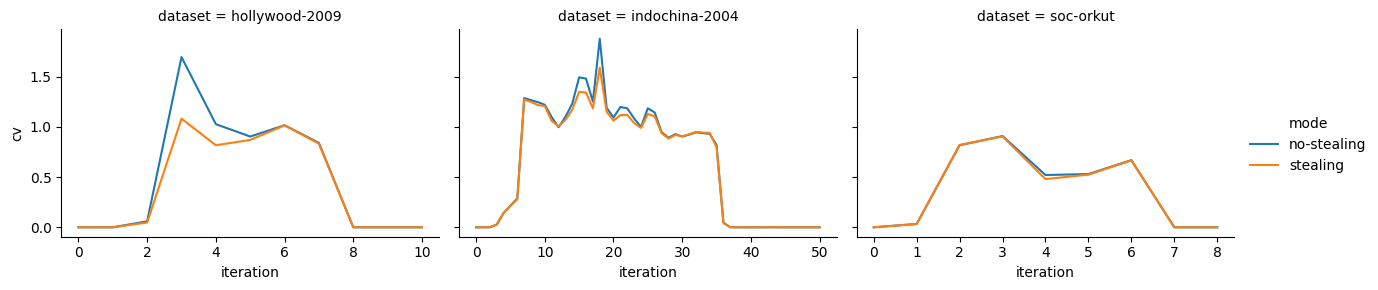

In [7]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Mean CV per iteration (across runs) using FacetGrid

def geo_mean(series, eps=1e-12):
    vals = series.to_numpy(dtype=float)
    if (vals <= 0).any():
        vals = np.maximum(vals, eps)
    return float(np.exp(np.mean(np.log(vals))))

mean_cv = (
    df_gini
    .groupby(["dataset", "mode", "iteration"], as_index=False)["cv"]
    .apply(geo_mean)
    .rename(columns={"cv": "cv"})
)

mean_cv["mode"] = pd.Categorical(mean_cv["mode"], categories=["no-stealing", "stealing"], ordered=True)
mean_cv["dataset"] = pd.Categorical(mean_cv["dataset"], categories=sorted(df_gini["dataset"].unique()), ordered=True)

sns.relplot(
    data=mean_cv,
    x="iteration",
    y="cv",
    hue="mode",
    col="dataset",
    kind="line",
    height=3,
    aspect=1.4,
    facet_kws={"sharey": True, "sharex": False},
)
plt.xlabel("iteration")
plt.ylabel("overall CV (block dispersion)")
plt.show()


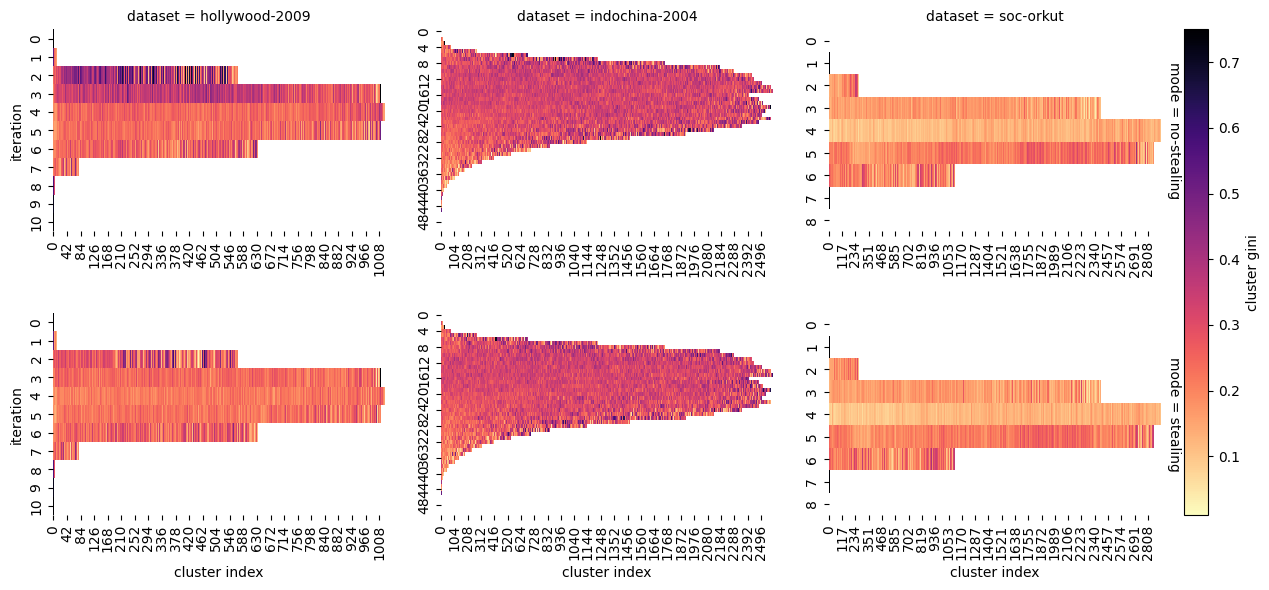

In [12]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Cluster Gini heatmap using FacetGrid
plot_df = (
    df_cluster_gini
    .groupby(["dataset", "mode", "iteration", "cluster"], as_index=False)["gini"]
    .mean()
)

plot_df["mode"] = pd.Categorical(plot_df["mode"], categories=["no-stealing", "stealing"], ordered=True)
plot_df["dataset"] = pd.Categorical(plot_df["dataset"], categories=sorted(df_cluster_gini["dataset"].unique()), ordered=True)

vmin = plot_df["gini"].min()
vmax = plot_df["gini"].max()


def facet_heatmap(data, **kwargs):
    pivot = data.pivot(index="iteration", columns="cluster", values="gini").sort_index()
    ax = plt.gca()
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="magma_r",
        vmin=vmin,
        vmax=vmax,
        cbar=False,
    )


g = sns.FacetGrid(
    plot_df,
    row="mode",
    col="dataset",
    margin_titles=True,
    height=3,
    aspect=1.4,
    sharex=False,
    sharey=False,
)

g.map_dataframe(facet_heatmap)

g.set_axis_labels("cluster index", "iteration")

mappable = plt.cm.ScalarMappable(cmap="magma_r")
mappable.set_array(plot_df["gini"].to_numpy())
g.fig.colorbar(mappable, ax=g.axes, fraction=0.03, pad=0.02, label="cluster gini")

plt.show()


Barplot Showing the number of processed edges by each thread-block.

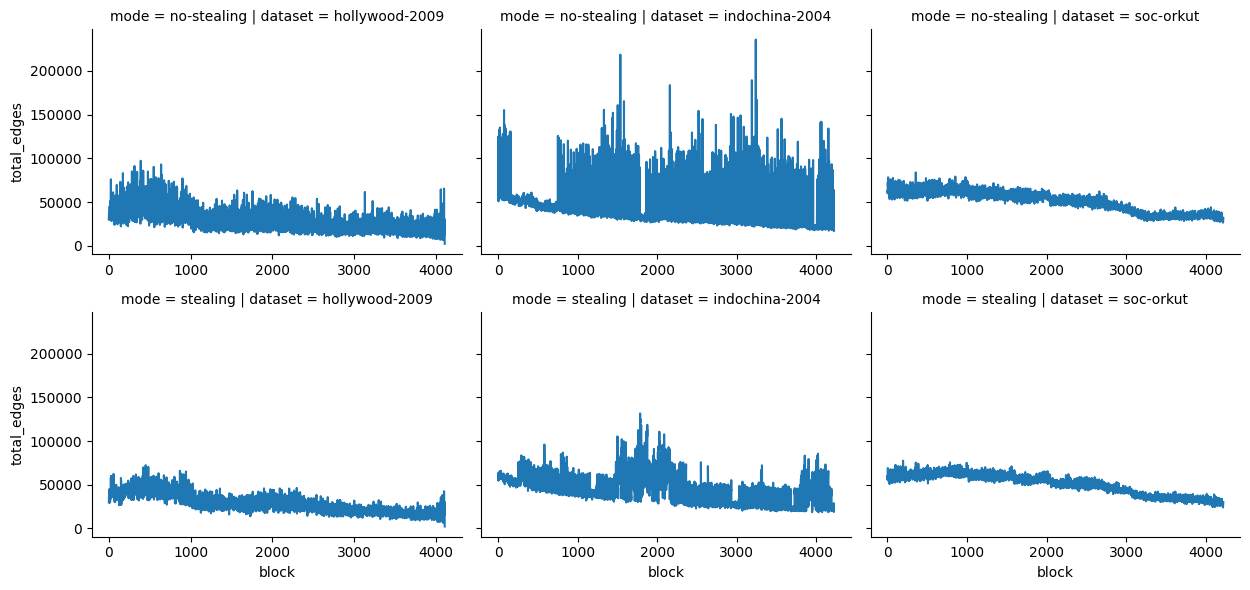

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Line plot: mean across runs, sum across iterations
plot_df = (
    df_edges
    .groupby(["dataset", "mode", "run", "block"], as_index=False)["edges"]
    .sum()
    .groupby(["dataset", "mode", "block"], as_index=False)["edges"]
    .mean()
    .rename(columns={"edges": "total_edges"})
)

plot_df["mode"] = pd.Categorical(plot_df["mode"], categories=["no-stealing", "stealing"], ordered=True)
plot_df["dataset"] = pd.Categorical(plot_df["dataset"], categories=sorted(df_edges["dataset"].unique()), ordered=True)

sns.relplot(
    data=plot_df,
    x="block",
    y="total_edges",
    row="mode",
    col="dataset",
    kind="line",
    height=3,
    aspect=1.4,
    facet_kws={"sharex": True, "sharey": True},
)
plt.show()

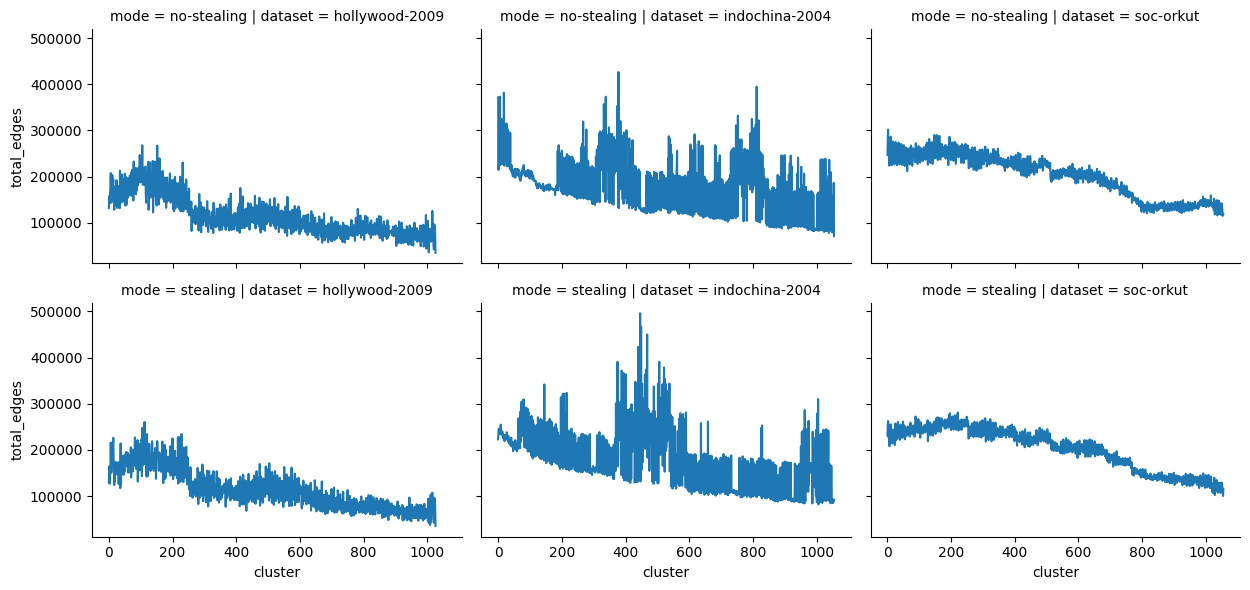

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Line plot: mean across runs, sum across iterations (per cluster)
plot_df = (
    df_cluster_edges
    .groupby(["dataset", "mode", "run", "cluster"], as_index=False)["edges"]
    .sum()
    .groupby(["dataset", "mode", "cluster"], as_index=False)["edges"]
    .mean()
    .rename(columns={"edges": "total_edges"})
)

plot_df["mode"] = pd.Categorical(plot_df["mode"], categories=["no-stealing", "stealing"], ordered=True)
plot_df["dataset"] = pd.Categorical(plot_df["dataset"], categories=sorted(df_cluster_edges["dataset"].unique()), ordered=True)

sns.relplot(
    data=plot_df,
    x="cluster",
    y="total_edges",
    row="mode",
    col="dataset",
    kind="line",
    height=3,
    aspect=1.4,
    facet_kws={"sharex": True, "sharey": True},
)
plt.show()


Heatmap Showing the number of processed edges by each thread-block during each iteration.

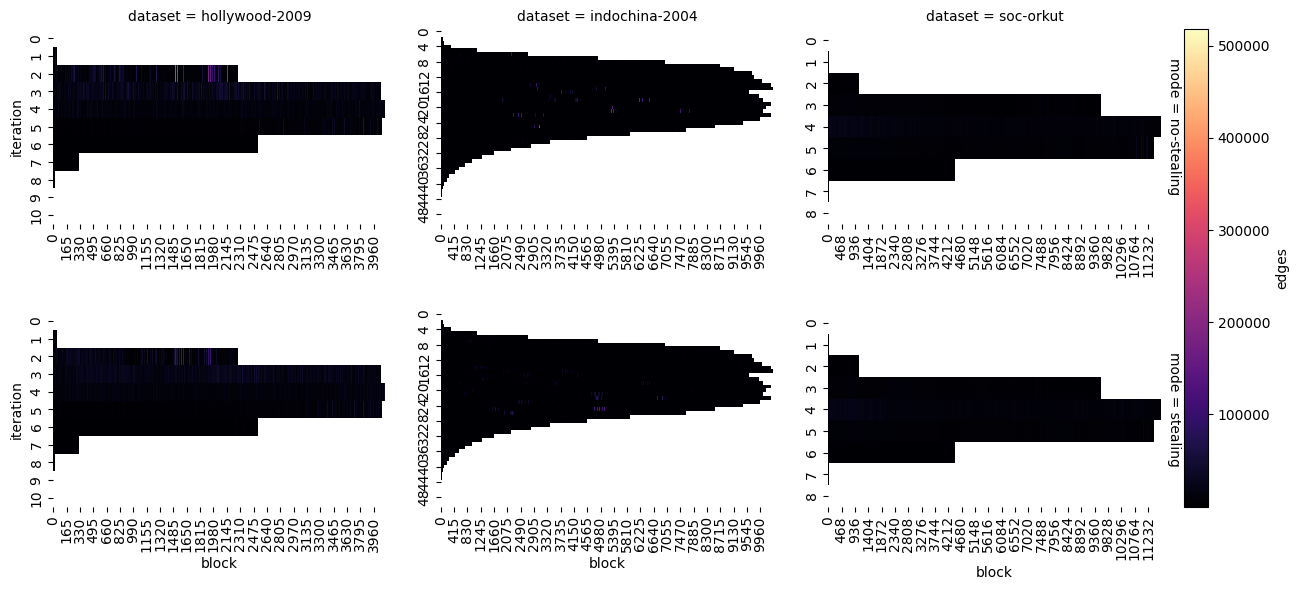

In [10]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Heatmap: edges per block per iteration (averaged across runs) using FacetGrid

plot_df = (
    df_edges
    .groupby(["dataset", "mode", "iteration", "block"], as_index=False)["edges"]
    .mean()
)

# Keep a stable facet order
plot_df["mode"] = pd.Categorical(plot_df["mode"], categories=["no-stealing", "stealing"], ordered=True)
plot_df["dataset"] = pd.Categorical(plot_df["dataset"], categories=sorted(df_edges["dataset"].unique()), ordered=True)

vmin = plot_df["edges"].min()
vmax = plot_df["edges"].max()


def facet_heatmap(data, **kwargs):
    pivot = data.pivot(index="iteration", columns="block", values="edges").sort_index()
    ax = plt.gca()
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="magma",
        vmin=vmin,
        vmax=vmax,
        cbar=False,
    )


g = sns.FacetGrid(
    plot_df,
    row="mode",
    col="dataset",
    margin_titles=True,
    height=3,
    aspect=1.4,
    sharex=False,
    sharey=False,
)

g.map_dataframe(facet_heatmap)

g.set_axis_labels("block", "iteration")

# Add a single colorbar
mappable = plt.cm.ScalarMappable(cmap="magma")
mappable.set_array(plot_df["edges"].to_numpy())
cb = g.fig.colorbar(mappable, ax=g.axes, fraction=0.03, pad=0.02, label="edges")

plt.show()

